<a href="https://colab.research.google.com/github/AguilarJrr/THE_CORE/blob/main/practica_mineria_videojuegos_alumnos_guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica guiada de Minería de Datos para Ingeniería de Videojuegos

## Caso práctico
Trabajas en el equipo de **Game Analytics** de un estudio que gestiona un videojuego online multijugador.
Dispones de un dataset con telemetría agregada de jugadores y debes analizarlo para encontrar patrones de comportamiento y construir un modelo sencillo de **churn**.

## Qué se trabaja en esta práctica
- Comprensión del problema
- Calidad de datos
- Limpieza y transformación
- Exploración visual
- Reducción de dimensionalidad con **PCA**
- Modelo base de clasificación

## Instrucciones
- En algunas celdas ya tienes parte del código hecha.
- Tendrás que completar las zonas marcadas con `# TODO`.
- No se trata solo de ejecutar: **interpreta** lo que ves.


## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO: importa seaborn con el alias habitual
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.figure(figsize=(8,5))
pd.set_option('display.max_columns', None)


<Figure size 800x500 with 0 Axes>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## 2. Carga del dataset

In [ ]:
ruta = 'videojuegos_online_telemetria.csv'

# TODO: carga el CSV en un DataFrame llamado df
df = pd.read_csv(ruta)

# TODO: muestra las 5 primeras filas
display(df.head())

,PlayerID,Age,Region,Platform,PreferredGenre,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
0,P0001,22.0,LATAM,PC,RPG,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,0
1,P0002,21.0,EU,PC,Shooter,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,0
2,P0003,40.0,LATAM,Mobile,Shooter,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,0
3,P0004,37.0,NaN,PC,Shooter,0,48.0,9,40,39,0.225,8.83,NaN,1,41,2,0
4,P0005,28.0,EU,Console,Shooter,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,1


### Preguntas rápidas
1. ¿Qué representa cada fila?
2. ¿Qué variable parece ser la variable objetivo?
3. ¿Qué decisiones de producto o diseño podría apoyar este análisis?


1.  **Cada fila es** la información de un jugador distinto en el juego. Es como una ficha de cada persona que juega.
2.  **La variable objetivo** es Churn30D. Nos dice si un jugador dejó de jugar en los últimos 30 días.
3.  **Este análisis puede ayudar a:**
    *   Saber quiénes podrían irse: Identificar a los jugadores que están a punto de dejar el juego para intentar que se queden.
    *   Mejorar el juego: Entender qué cosas del juego hacen que los jugadores se queden o se vayan, para hacer el juego más divertido o justo.
    *   Decidir qué ofrecer en la tienda: Ver si lo que la gente gasta en el juego afecta si se quedan o no, para ajustar las ofertas.

## 3. Comprensión inicial del dataset

In [ ]:
print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
display(df.dtypes)

print('\nResumen estadístico de variables numéricas:')
display(df.describe())


Dimensiones del dataset: (558, 17)

Tipos de datos:


,0
PlayerID,object
Age,float64
Region,object
Platform,object
PreferredGenre,object
SessionsPerWeek,int64
AvgSessionMinutes,float64
DaysSinceLastLogin,int64
PlayerLevel,int64
MatchesPlayedLast30D,int64



Resumen estadístico de variables numéricas:


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
count,546.000000,558.000000,546.000000,558.000000,558.000000,558.000000,546.000000,546.000000,546.000000,558.000000,558.000000,558.000000,558.000000
mean,27.893773,4.500000,78.578755,7.646953,35.127240,27.048387,0.512256,14.318462,7.569597,0.546595,22.206093,1.080645,0.408602
std,7.256991,1.909769,41.368230,5.911898,17.631983,14.633996,0.155886,47.664126,4.732448,0.498271,11.713309,1.083060,0.492017
min,16.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.123000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,3.000000,60.000000,3.000000,23.000000,17.000000,0.409000,3.252500,4.000000,0.000000,14.000000,0.000000,0.000000
50%,28.000000,4.000000,76.000000,7.000000,36.000000,27.000000,0.512500,8.050000,7.000000,1.000000,22.000000,1.000000,0.000000
75%,34.000000,6.000000,93.000000,11.000000,47.000000,37.000000,0.619000,16.750000,11.000000,1.000000,30.000000,2.000000,1.000000
max,40.000000,10.000000,600.000000,26.000000,86.000000,69.000000,0.950000,999.000000,25.000000,1.000000,61.000000,5.000000,1.000000


In [ ]:
# TODO: muestra cuántos jugadores hay por plataforma
# Pista: value_counts()
display(df['Platform'].value_counts())

# TODO: muestra cuántos jugadores hay por región
display(df['Region'].value_counts())

,count
Platform,
PC,227
Console,159
Mobile,104
pc,68


,count
Region,
EU,216
APAC,81
LATAM,77
Europe,54


## 4. Calidad del dato

In [ ]:
print('Valores nulos por columna:')
display(df.isna().sum().sort_values(ascending=False))

print('Filas duplicadas:', df.duplicated().sum())


Valores nulos por columna:


,0
Region,130
InGamePurchase,12
Age,12
AvgSessionMinutes,12
WinRate,12
FriendsInGame,12
PlayerID,0
PreferredGenre,0
Platform,0
PlayerLevel,0


Filas duplicadas: 8


In [ ]:
print('Valores únicos de Region:')
print(df['Region'].unique())

print('\nValores únicos de Platform:')
print(df['Platform'].unique())


Valores únicos de Region:
['LATAM' 'EU' nan 'APAC' 'Europe']

Valores únicos de Platform:
['PC' 'Mobile' 'Console' 'pc']


### Pregunta
¿Detectas inconsistencias en variables categóricas? Escríbelas aquí:

- **'Region'**: Contiene valores 'Europe' que es una duplicación de 'EU', y también presenta valores nulos (nan).
- **'Platform'**: Contiene 'pc' que es una duplicación de 'PC' (diferencia de mayúsculas y minúsculas).


## 5. Limpieza de datos

In [ ]:
df_clean = df.copy()

# Eliminamos duplicados
df_clean = df_clean.drop_duplicates()

# TODO: corrige categorías inconsistentes
# Ejemplos esperados:
# - 'pc' debe pasar a 'PC'
# - 'Europe' debe pasar a 'EU'
df_clean['Platform'] = df_clean['Platform'].replace({'pc': 'PC'})
df_clean['Region'] = df_clean['Region'].replace({'Europe': 'EU'})


print(df_clean.shape)

(550, 17)


In [ ]:
# Imputación sencilla de nulos en variables numéricas con la mediana
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Imputación de nulos en variables categóricas con la moda (para la columna 'Region')
df_clean['Region'] = df_clean['Region'].fillna(df_clean['Region'].mode()[0])

# TODO: comprueba que ya no queden nulos
print('Total de valores nulos restantes:', df_clean.isna().sum().sum())

Total de valores nulos restantes: 0


### Reflexión
¿Por qué tiene sentido usar la **mediana** en vez de la media en algunas variables de telemetría?


Imagina que tienes los datos de cuánto juega la gente. La media es como el 'promedio normal'. Pero si hay uno o dos jugadores que juegan muchísimas horas (mucho más que el resto), estos números tan grandes 'engañan' a la media y hacen que parezca que todos juegan mucho más de lo que es verdad.

La mediana es diferente: es el número que está justo en medio de todos los datos cuando los pones en orden. Así, si unos pocos juegan una barbaridad, a la mediana no le importa tanto y te da un número que representa mejor lo que hace la mayoría de la gente. Por eso, para datos de juegos donde hay algunos jugadores que se salen de lo normal, la mediana es una medida más justa y útil.

## 6. Exploración visual

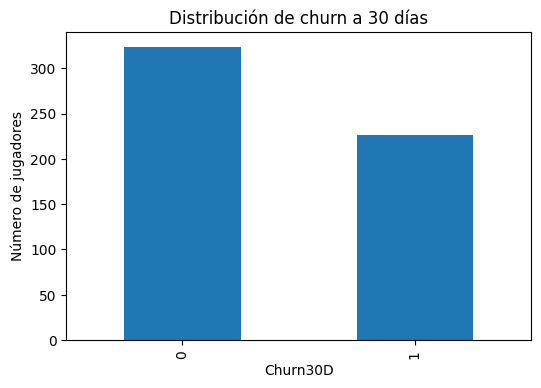

In [ ]:
plt.figure(figsize=(6,4))
df_clean['Churn30D'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de churn a 30 días')
plt.xlabel('Churn30D')
plt.ylabel('Número de jugadores')
plt.show()


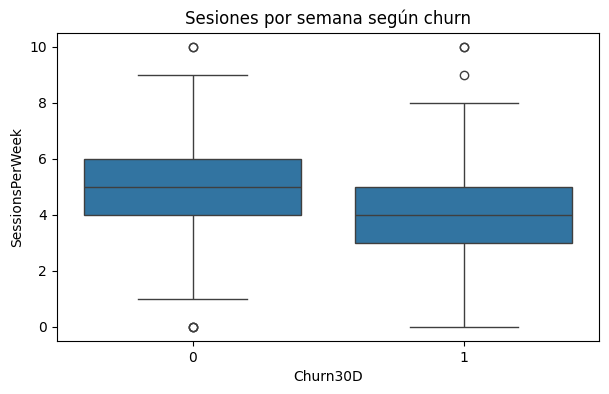

In [ ]:
plt.figure(figsize=(7,4))
# TODO: crea un boxplot de SessionsPerWeek separado por Churn30D
# Pista: sns.boxplot(data=..., x='Churn30D', y='SessionsPerWeek')
sns.boxplot(data=df_clean, x='Churn30D', y='SessionsPerWeek')

plt.title('Sesiones por semana según churn')
plt.show()

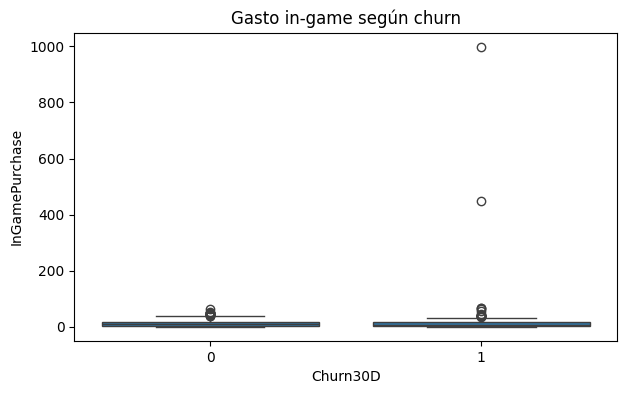

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='InGamePurchase')
plt.title('Gasto in-game según churn')
plt.show()


In [ ]:
# TODO: calcula el churn medio por plataforma
# Pista: groupby + mean
display(df_clean.groupby('Platform')['Churn30D'].mean())

,Churn30D
Platform,
Console,0.474684
Mobile,0.394231
PC,0.381944


### Preguntas de interpretación

1.  **¿Los jugadores con menos sesiones parecen abandonar más?**
    *   Sí, observando el boxplot de `SessionsPerWeek` por `Churn30D`, se ve claramente que los jugadores con `Churn30D = 1` (los que abandonan) tienen una mediana y un rango intercuartílico de sesiones por semana significativamente más bajos que los jugadores con `Churn30D = 0` (los que se quedan).

2.  **¿Parece existir relación entre gasto y retención?**
    *   Sí, el boxplot de `InGamePurchase` por `Churn30D` sugiere una relación. Los jugadores que abandonan (`Churn30D = 1`) tienden a tener un gasto in-game menor, con una mediana y distribución más bajas en comparación con los jugadores que se retienen (`Churn30D = 0`).

3.  **¿Ves alguna señal útil para un equipo de LiveOps?**
    *   **Indicadores de riesgo de churn**: Los jugadores con **pocas sesiones por semana** y **bajo gasto in-game** son fuertes candidatos a abandonar el juego. LiveOps podría monitorizar estas métricas y lanzar campañas de re-engagement o incentivos dirigidos a estos segmentos.
    *   **Diferencias por plataforma**: Si el churn medio por plataforma revelara alguna variación significativa (aunque no se ha representado visualmente), el equipo de LiveOps podría diseñar estrategias de retención específicas para cada plataforma (ej. eventos exclusivos para móvil, optimización de rendimiento en PC, etc.).

## 7. Preparación para modelado

In [ ]:
y = df_clean['Churn30D']

# Quitamos la variable objetivo y el identificador
X = df_clean.drop(columns=['Churn30D', 'PlayerID'])

# Convertimos variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

print('Dimensiones de X:', X.shape)
display(X.head())


Dimensiones de X: (550, 21)


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Region_EU,Region_LATAM,Platform_Mobile,Platform_PC,PreferredGenre_MOBA,PreferredGenre_RPG,PreferredGenre_Shooter,PreferredGenre_Sports,PreferredGenre_Strategy
0,22.0,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,False,True,False,True,False,True,False,False,False
1,21.0,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,True,False,False,True,False,False,True,False,False
2,40.0,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,False,True,True,False,False,False,True,False,False
3,37.0,0,48.0,9,40,39,0.225,8.83,7.0,1,41,2,True,False,False,True,False,False,True,False,False
4,28.0,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,True,False,False,False,False,False,True,False,False


## 8. Estandarización y PCA

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

display(var_exp[:10])
display(var_exp_acum[:10])


array([0.08264248, 0.07445493, 0.06456518, 0.06322402, 0.06114867,
       0.05834284, 0.05755401, 0.05276106, 0.05140914, 0.0489173 ])

array([0.08264248, 0.15709741, 0.22166259, 0.28488661, 0.34603528,
       0.40437812, 0.46193213, 0.51469319, 0.56610233, 0.61501962])

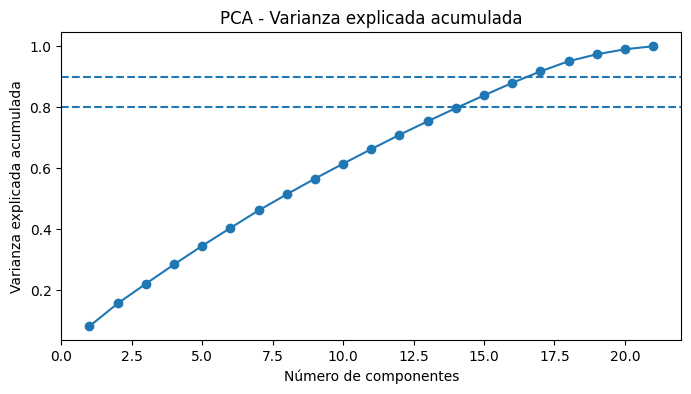

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(var_exp_acum)+1), var_exp_acum, marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.axhline(y=0.90, linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.show()


In [ ]:
# TODO: crea un PCA de 2 componentes y transforma X_scaled
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# TODO: crea un DataFrame llamado pca_df con columnas PC1 y PC2
# Añade también la columna Churn30D
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Churn30D'] = y.reset_index(drop=True)

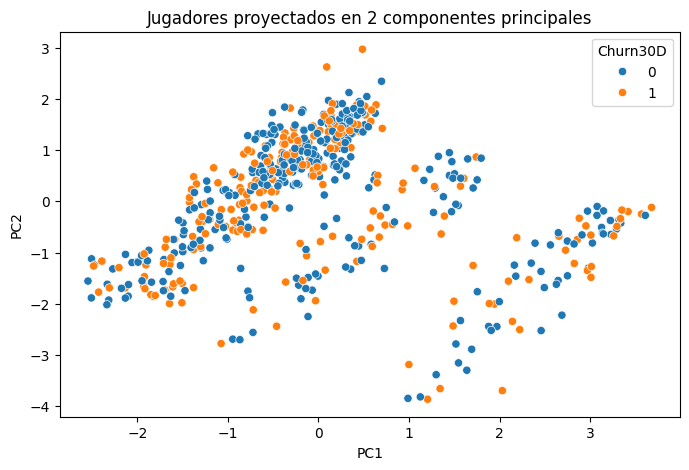

In [ ]:
plt.figure(figsize=(8,5))
# TODO: crea un scatterplot de PC1 vs PC2 coloreado por Churn30D
# Pista: sns.scatterplot(...)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Churn30D')

plt.title('Jugadores proyectados en 2 componentes principales')
plt.show()

### Preguntas de interpretación

1.  **¿Se aprecia alguna separación visual entre perfiles?**
    *   Observando el scatterplot de `PC1` vs `PC2` coloreado por `Churn30D`, se puede ver que los puntos azules (`Churn30D = 0`, no churn) y los naranjas (`Churn30D = 1`, churn) están algo mezclados, aunque los jugadores con churn (`Churn30D = 1`) tienden a concentrarse más en ciertas zonas (por ejemplo, valores más altos de `PC1`), mientras que los que no churn (`Churn30D = 0`) están más dispersos o en otras áreas. No hay una separación "limpia" y perfecta, pero sí una tendencia a agruparse diferencialmente.

2.  **¿Qué ventaja aporta PCA en un problema con muchas variables?**
    *   **Reducción de dimensionalidad:** Permite reducir el número de variables manteniendo la mayor parte de la información (varianza), lo que simplifica el análisis y la visualización.
    *   **Visualización:** Facilita la representación de datos complejos en 2D o 3D, como se ve en el scatterplot, ayudando a identificar patrones o clusters.
    *   **Eliminación de ruido y redundancia:** Al combinar variables correlacionadas y enfocarse en las componentes con mayor varianza, puede ayudar a eliminar información redundante y ruido.
    *   **Mejora de modelos:** En algunos casos, los modelos de machine learning pueden funcionar mejor con menos características (componentes principales) y menos multicolinealidad.

3.  **¿Qué inconveniente tiene usar PCA desde el punto de vista de interpretabilidad?**
    *   **Pérdida de interpretabilidad:** Los componentes principales (`PC1`, `PC2`, etc.) son combinaciones lineales de las variables originales. Esto significa que ya no representan una característica directa del jugador (como 'horas de juego' o 'gasto'), sino una mezcla abstracta. Es difícil decir qué significa exactamente 'tener un PC1 alto' en términos del comportamiento real del jugador, lo que dificulta extraer conclusiones directas para un equipo de negocio.

## 9. Modelo base de clasificación

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(412, 21) (138, 21)


In [ ]:
modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)


In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)


Accuracy: 0.6304347826086957

Classification report:

              precision    recall  f1-score   support

           0       0.65      0.81      0.72        81
           1       0.58      0.37      0.45        57

    accuracy                           0.63       138
   macro avg       0.62      0.59      0.59       138
weighted avg       0.62      0.63      0.61       138

Matriz de confusión:
[[66 15]
 [36 21]]


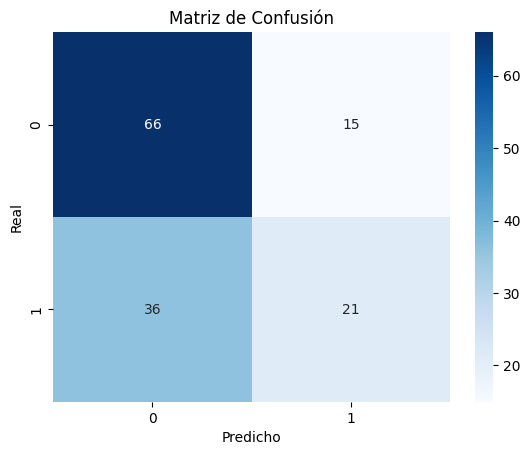

In [ ]:
# TODO: representa la matriz de confusión con un heatmap
# Pista: sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### 10. Conclusiones finales

Responde brevemente:

1.  **¿Qué variables parecen más relacionadas con el churn?**
    *   Las variables más relacionadas con el churn son el **número de sesiones por semana (`SessionsPerWeek`)** y el **gasto in-game (`InGamePurchase`)**. Los jugadores que abandonan (`Churn30D = 1`) tienden a tener menos sesiones y un gasto menor.
    *   Aunque no se ha analizado en detalle aquí, las variables relacionadas con el progreso (`ProgressLevel`, `AchievementsUnlocked`) y la socialización (`FriendsAdded`) también podrían ser muy influyentes, ya que suelen estar ligadas al compromiso del jugador.

2.  **¿Qué acciones propondrías al equipo de diseño, retención o monetización?**
    *   **Equipo de Retención (LiveOps):**
        *   **Monitorizar `SessionsPerWeek` e `InGamePurchase`:** Identificar jugadores con baja actividad y/o bajo gasto para aplicar estrategias de re-engagement personalizadas (ej. notificaciones push, recompensas por iniciar sesión, ofertas especiales).
        *   **Programas de fidelización:** Incentivar la actividad continua y el gasto con programas de puntos o recompensas exclusivas.
    *   **Equipo de Diseño:**
        *   **Mejorar el tutorial/onboarding:** Asegurarse de que los nuevos jugadores comprendan bien el juego y encuentren motivación para continuar.
        *   **Fomentar la socialización:** Implementar más características multijugador, gremios o eventos cooperativos para aumentar el compromiso.
        *   **Contenido recurrente:** Asegurar un flujo constante de contenido nuevo y atractivo para mantener el interés de los jugadores a largo plazo.
    *   **Equipo de Monetización:**
        *   **Ofertas personalizadas:** Adaptar las ofertas in-game a los patrones de gasto y actividad de cada jugador para maximizar la conversión y la retención.
        *   **Bundles de valor:** Ofrecer paquetes atractivos que incentiven el gasto pero también la permanencia en el juego.

3.  **¿Qué has aprendido sobre preparación de datos y PCA en un contexto de videojuegos?**
    *   **Preparación de Datos:** En un contexto de videojuegos, es crucial la limpieza de datos, especialmente la corrección de inconsistencias en variables categóricas (ej. 'pc' vs 'PC', 'Europe' vs 'EU') y la gestión de valores nulos. La **imputación con la mediana** es a menudo preferible a la media para variables de telemetría debido a la presencia de outliers y distribuciones asimétricas, que son comunes en los datos de comportamiento de jugadores.
    *   **PCA (Análisis de Componentes Principales):** Hemos visto que el PCA es una herramienta muy útil para la **reducción de dimensionalidad** y la **visualización** de conjuntos de datos con muchas variables, lo cual es típico en telemetría de juegos. Permite simplificar la complejidad y visualizar patrones que de otro modo serían difíciles de detectar. Sin embargo, su principal inconveniente es la **pérdida de interpretabilidad** de las nuevas componentes, lo que dificulta traducir los resultados directamente en acciones de negocio específicas sin un análisis adicional de las cargas de los componentes.